In [107]:
from read_cmip import *
import matplotlib.pyplot as plt
from wrf_parallel import get_var_p_lvl, get_mean_var_p

In [2]:
model="ACCESS1-0"; experiment="historical"; ensemble="r1i1p1"; year=2000; region="global"; cmip_ver=5; al33=False; group=""; ver6hr=""; ver3hr=""; project="CMIP"
if region == "sa_small":
        start_lat = -38; end_lat = -26; start_lon = 132; end_lon = 142
elif region == "aus":
        start_lat = -44.525; end_lat = -9.975; start_lon = 111.975; end_lon = 156.275
elif region == "global":
        start_lat = -70; end_lat = 70; start_lon = -180; end_lon = 179.75
else:
        raise ValueError("INVALID REGION\n")
domain = [start_lat,end_lat,start_lon,end_lon]

In [12]:
hus_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/6hr/atmos/"+ensemble+"/hus/latest/*6hrLev*"))
ta_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/6hr/atmos/"+ensemble+"/ta/latest/*6hrLev*"))
ps_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/3hr/atmos/"+ensemble+"/ps/latest/*"))
hus_fid = get_fid( hus_files, year)
ta_fid = get_fid( ta_files, year)
ps_fid = get_fid( ps_files, year)

#Load the data
hus = xr.open_mfdataset([hus_files[i] for i in hus_fid], use_cftime=True)
ta = xr.open_mfdataset([ta_files[i] for i in ta_fid], use_cftime=True)
ps = xr.open_mfdataset([ps_files[i] for i in ps_fid], use_cftime=True)

#Change lons
hus.coords['lon'] = (hus.coords['lon'] + 180) % 360 - 180; hus = hus.sortby(hus.lon)
ta.coords['lon'] = (ta.coords['lon'] + 180) % 360 - 180; ta = ta.sortby(ta.lon)
ps.coords['lon'] = (ps.coords['lon'] + 180) % 360 - 180; ps = ps.sortby(ps.lon)

#Trim spatially
domain[0] = domain[0]-5
domain[1] = domain[1]+5
domain[2] = domain[2]-5
domain[3] = domain[3]+5
hus = trim_cmip5(hus, domain, year)
ta = trim_cmip5(ta, domain, year)
ps = trim_cmip5(ps, domain, year)

#Trim to 6 days for testing
hus = hus.isel({"time":[4,6]})
common_times = np.array(list(set(hus.time.values) & set(ta.time.values) & set(ps.time.values)))
hus = hus.sel({"time": np.in1d(hus.time, common_times)})
ta = ta.sel({"time": np.in1d(ta.time, common_times)})
ps = ps.sel({"time": np.in1d(ps.time, common_times)})


/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/xarray/backends/api.py:783: FutureWarning: In xarray version 0.13 `auto_combine` will be deprecated.
  coords=coords)
/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/xarray/backends/api.py:783: FutureWarning: The datasets supplied have global dimension coordinates. You may want
to use the new `combine_by_coords` function (or the
`combine='by_coords'` option to `open_mfdataset` to order the datasets
before concatenation. Alternatively, to continue concatenating based
on the order the datasets are supplied in in future, please use the
new `combine_nested` function (or the `combine='nested'` option to
open_mfdataset).
  coords=coords)


In [13]:
#Test on data with hybrid-height coordinates
z = hus.lev + (hus.b * hus.orog)
orog = hus.orog.values
q = hus.hus / (1 - hus.hus)
tv = ta.ta * ( ( q + 0.622) / (0.622 * (1+q) ) )

In [14]:
def hypsometric_p(p_sfc, z, tv, terrain):

        #TODO Sort out the axis/shape. Check this works on ERA5. Check this works on hybrid-pressure level data (to calculate Z)

        #Get the difference in height between each level. Need to give this function the height axis
        zdiff = np.diff(z, axis=1, prepend=terrain[:,np.newaxis,:,:])
        #Calculate the second term of the hypsometric equation
        T2 = np.exp( (-9.8 * zdiff) / (287 * (tv) ) )
        #Initialise the full pressure array
        p_full = np.empty(tv.shape)
        p_full[:,0,:,:] = p_sfc * T2[:,0,:,:]
        for i in np.arange(1,p_full.shape[1]):
                p_full[:,i,:,:] = p_full[:,i-1,:,:] * T2[:,i,:,:]
                        
        return p_full
    
z = np.swapaxes(z, 0, 1).values
orog = orog[0]
p = hypsometric_p(ps.ps.values, z, tv.values, np.tile(orog[np.newaxis], (ta.ta.shape[0],1,1)))

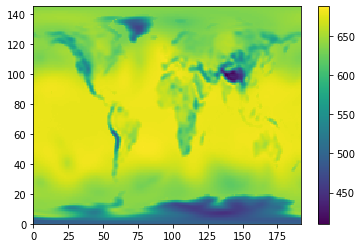

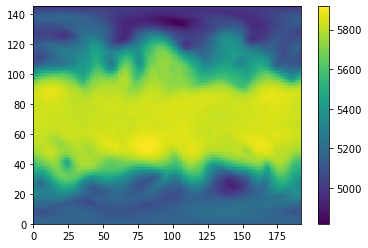

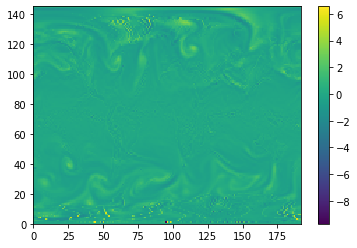

In [22]:
import matplotlib.pyplot as plt
from wrf_parallel import get_var_p_lvl

plt.pcolormesh(p[0,12]/100.); plt.colorbar()
plt.figure()
plt.pcolormesh( get_var_p_lvl(z[0,:,:,:], p[0]/100., 500) ); plt.colorbar()

x, y = np.meshgrid(ta.lon.values,ta.lat.values)
dx, dy = mpcalc.lat_lon_grid_deltas(x,y)
laplacian = np.array(mpcalc.laplacian(get_var_p_lvl(z[1], p[1]/100., 500),deltas=[dy,dx])*1e9)
plt.figure()
plt.pcolormesh(laplacian); plt.colorbar()

In [98]:
#TRY FOR A MODEL ON HEIGHT COORDINATES

model="MRI-CGCM3"; experiment="historical"; ensemble="r1i1p1"; year=2000; region="global"; cmip_ver=5; al33=False; group=""; ver6hr=""; ver3hr=""; project="CMIP"
if region == "sa_small":
        start_lat = -38; end_lat = -26; start_lon = 132; end_lon = 142
elif region == "aus":
        start_lat = -44.525; end_lat = -9.975; start_lon = 111.975; end_lon = 156.275
elif region == "global":
        start_lat = -70; end_lat = 70; start_lon = -180; end_lon = 179.75
else:
        raise ValueError("INVALID REGION\n")
domain = [start_lat,end_lat,start_lon,end_lon]

hus_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/6hr/atmos/"+ensemble+"/hus/latest/*6hrLev*"))
ta_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/6hr/atmos/"+ensemble+"/ta/latest/*6hrLev*"))
psl_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/6hr/atmos/"+ensemble+"/psl/latest/*6hrPlev*"))
ps_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/3hr/atmos/"+ensemble+"/ps/latest/*"))
huss_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/3hr/atmos/"+ensemble+"/huss/latest/*"))
tas_files = np.sort(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
            model+"/"+experiment+\
            "/3hr/atmos/"+ensemble+"/tas/latest/*"))
hus_fid = get_fid( hus_files, year)
ta_fid = get_fid( ta_files, year)
psl_fid = get_fid( psl_files, year)
ps_fid = get_fid( ps_files, year)
huss_fid = get_fid( huss_files, year)
tas_fid = get_fid( tas_files, year)

#Load the data
hus = xr.open_mfdataset([hus_files[i] for i in hus_fid], use_cftime=True)
ta = xr.open_mfdataset([ta_files[i] for i in ta_fid], use_cftime=True)
psl = xr.open_mfdataset([psl_files[i] for i in psl_fid], use_cftime=True)
ps = xr.open_mfdataset([ps_files[i] for i in ps_fid], use_cftime=True)
huss = xr.open_mfdataset([huss_files[i] for i in huss_fid], use_cftime=True)
tas = xr.open_mfdataset([tas_files[i] for i in tas_fid], use_cftime=True)

#Change lons
hus.coords['lon'] = (hus.coords['lon'] + 180) % 360 - 180; hus = hus.sortby(hus.lon)
ta.coords['lon'] = (ta.coords['lon'] + 180) % 360 - 180; ta = ta.sortby(ta.lon)
psl.coords['lon'] = (psl.coords['lon'] + 180) % 360 - 180; psl = psl.sortby(psl.lon)
ps.coords['lon'] = (ps.coords['lon'] + 180) % 360 - 180; ps = ps.sortby(ps.lon)
huss.coords['lon'] = (huss.coords['lon'] + 180) % 360 - 180; huss = huss.sortby(huss.lon)
tas.coords['lon'] = (tas.coords['lon'] + 180) % 360 - 180; tas = tas.sortby(tas.lon)
    
#Trim spatially
domain[0] = domain[0]-5
domain[1] = domain[1]+5
domain[2] = domain[2]-5
domain[3] = domain[3]+5
hus = trim_cmip5(hus, domain, year)
ta = trim_cmip5(ta, domain, year)
psl = trim_cmip5(psl, domain, year)
ps = trim_cmip5(ps, domain, year)
huss = trim_cmip5(huss, domain, year)
tas = trim_cmip5(tas, domain, year)
    
#Trim to 6 days for testing
hus = hus.isel({"time":[4,6]})
common_times = np.array(list(set(hus.time.values) & set(ta.time.values) & set(psl.time.values) & set(ps.time.values) & set(huss.time.values) & set(tas.time.values)))
hus = hus.sel({"time": np.in1d(hus.time, common_times)})
ta = ta.sel({"time": np.in1d(ta.time, common_times)})
psl = psl.sel({"time": np.in1d(psl.time, common_times)})
ps = ps.sel({"time": np.in1d(ps.time, common_times)})
huss = huss.sel({"time": np.in1d(huss.time, common_times)})
tas = tas.sel({"time": np.in1d(tas.time, common_times)})


/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/xarray/backends/api.py:783: FutureWarning: In xarray version 0.13 `auto_combine` will be deprecated.
  coords=coords)
/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/xarray/backends/api.py:783: FutureWarning: The datasets supplied have global dimension coordinates. You may want
to use the new `combine_by_coords` function (or the
`combine='by_coords'` option to `open_mfdataset` to order the datasets
before concatenation. Alternatively, to continue concatenating based
on the order the datasets are supplied in in future, please use the
new `combine_nested` function (or the `combine='nested'` option to
open_mfdataset).
  coords=coords)


In [99]:
names = []
for name, da in hus.data_vars.items():
    names.append(name)

if "p0" in names:
        p = (hus.a * hus.p0 + hus.b * hus.ps).transpose("time","lev","lat","lon")
elif "ap" in names:
        p = (hus.ap + hus.b * hus.ps).transpose("time","lev","lat","lon")
else:
        raise ValueError("Check the hybrid-pressure coordinate of this model")
q = hus.hus / (1 - hus.hus)
tv = ta.ta * ( ( q + 0.622) / (0.622 * (1+q) ) )
#z = (-287 * tv * (np.log( p / ps.ps)).transpose("time","lev","lat","lon") ) / 9.8
orog = xr.open_dataset(glob.glob("/g/data/r87/DRSv3/CMIP5/"+\
    model+"/historical/fx/atmos/r0i0p0/orog/latest/orog*.nc")[0])
if orog.lon.values.max() >= 350:
        orog.coords['lon'] = (orog.coords['lon'] + 180) % 360 - 180; orog = orog.sortby(orog.lon)
orog = trim_cmip5(orog.orog, domain, year).values
#orog[orog<0] = 0
#z = (z + orog).values

In [100]:
a=hus.ps.values; b=p.values; c=tv.values

In [101]:
sfc_q = huss.huss / (1 - huss.huss)
sfc_tv = tas.tas * ( ( sfc_q + 0.622) / (0.622 * (1+sfc_q) ) )
sfc_c = sfc_tv.values

In [102]:
def hypsometric_z(p_sfc, p, tv, sfc_tv, terrain):

        #Calculate the second term of the hypsometric equation
        T2 = (287 * tv) / 9.8

        #Initialise the full pressure array
        z_full = np.empty(tv.shape)
        tv0 = np.mean(np.stack([tv[:,0,:,:], sfc_tv]), axis=0)
        z_full[:,0,:,:] = np.log(p_sfc / p[:,0,:,:]) * ((287 * tv0) / 9.8)# + terrain
        for i in np.arange(1,z_full.shape[1]):
            temp_tv = np.mean(np.stack([tv[:,i-1,:,:], tv[:,i,:,:]]), axis=0)
            T2 = (287 * temp_tv) / 9.8
            z_full[:,i,:,:] = np.log(p[:,i-1,:,:]/p[:,i,:,:]) * T2 + z_full[:,i-1,:,:]

        return z_full

# def hypsometric_z(psl, p, tv):

#         #Calculate the second term of the hypsometric equation
#         T2 = (287 * tv) / 9.8

#         #Initialise the full pressure array
#         z_full = np.empty(tv.shape)
#         #tv0 = np.mean(np.stack([tv[:,0,:,:], sfc_tv]), axis=0)
#         z_full[:,0,:,:] = np.log(psl / p[:,0,:,:]) * ((287 * tv[:,0,:,:]) / 9.8)# + terrain
#         for i in np.arange(1,z_full.shape[1]):
#             temp_tv = np.mean(np.stack([tv[:,i-1,:,:], tv[:,i,:,:]]), axis=0)
#             T2 = (287 * temp_tv) / 9.8
#             z_full[:,i,:,:] = np.log(p[:,i-1,:,:]/p[:,i,:,:]) * T2 + z_full[:,i-1,:,:]

#         return z_full
    
#z = hypsometric_z(psl.psl.values, b, c)#, sfc_c)
z = hypsometric_z(a, b, c, sfc_c, np.tile(orog[np.newaxis], (ta.ta.shape[0],1,1)))

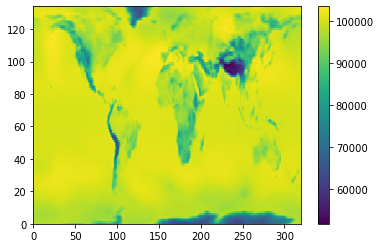

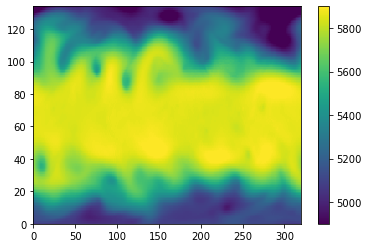

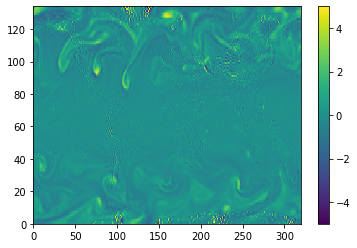

In [104]:
from scipy.ndimage import median_filter

plt.pcolormesh(p.values[1,0]); plt.colorbar(); plt.figure()

plt.pcolormesh((get_var_p_lvl(z[0,:,:,:], p.values[0]/100., 500))+orog, vmin=4900, vmax=5900); plt.colorbar()

x, y = np.meshgrid(ta.lon.values,ta.lat.values)
dx, dy = mpcalc.lat_lon_grid_deltas(x,y)
laplacian = np.array(mpcalc.laplacian((get_var_p_lvl(z[0,:,:,:], p.values[0]/100., 500)+orog),deltas=[dy,dx])*1e9)
plt.figure()
plt.pcolormesh(laplacian, vmin=-5, vmax=5); plt.colorbar()

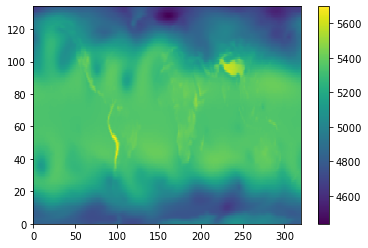

In [133]:
mean_tv = get_mean_var_p(c[0], p[0], a[0], 500, p[0], True) 
z500 = ((287 * mean_tv) / 9.8) * np.log(a[0]/50000)
plt.pcolormesh(z500+orog); plt.colorbar()

In [2]:
#TEST FOR ERA5

from era5_read import read_era5_rt52
start_lat = -70; end_lat = 70; start_lon = -180; end_lon = 179.75
domain = [start_lat,end_lat,start_lon,end_lon]
[eta,edp,ehur,ehgt,eterrain,ep,eps,emsl,eua,eva,euas,evas,etas,eta2d,ecp,etp,ewg10,ecape,esst,elon,elat,edate_list] = \
    read_era5_rt52(domain,[dt.datetime(2000,1,1), dt.datetime(2000,1,1)], pres=True,delta_t=1)

ep_3d = np.moveaxis(np.tile(ep,[eta.shape[2],eta.shape[3],1]),[0,1,2],[1,2,0]).\
        astype(np.float32)
eq = mpcalc.mixing_ratio_from_relative_humidity(ehur * units.units.percent, eta * units.units.degC, ep_3d * units.units.hectopascal)
etv = eta * ( ( eq + 0.622) / (0.622 * (1+eq) ) )

/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/pint/quantity.py:1488: RuntimeWarning: divide by zero encountered in log
  return ufunc(*mobjs)
/g/data/eg3/ab4502/miniconda3/envs/wrfpython3.6/lib/python3.6/site-packages/pint/quantity.py:888: RuntimeWarning: invalid value encountered in true_divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


In [31]:
def hypsometric_z(p_sfc, p, tv, terrain):

        #Calculate the second term of the hypsometric equation
        T2 = (287 * tv) / 9.8

        #Initialise the full pressure array
        z_full = np.empty(tv.shape)
        z_full[:,0,:,:] = (np.log(p_sfc / p[:,0,:,:]) * T2[:,0,:,:]) + terrain
        for i in np.arange(1,z_full.shape[1]):
               z_full[:,i,:,:] = np.log(p[:,i-1,:,:]/p[:,i,:,:]) * T2[:,i,:,:] + z_full[:,i-1,:,:]

        return z_full

def hypsometric_z2(mslp, p, tv, terrain):

        #Calculate the second term of the hypsometric equation
        T2 = (287 * tv) / 9.8

        #Initialise the full pressure array
        z_full = np.empty(tv.shape)
        z_full[:,0,:,:] = (np.log(mslp / p[:,0,:,:]) * T2[:,0,:,:])
        for i in np.arange(1,z_full.shape[1]):
               z_full[:,i,:,:] = np.log(p[:,i-1,:,:]/p[:,i,:,:]) * T2[:,i,:,:] + z_full[:,i-1,:,:]

        return z_full    
    
def hypsometric_p(p_sfc, z, tv, terrain):

        #Get the difference in height between each level. Need to give this function the height axis
        zdiff = np.diff(z, axis=1, prepend=0)
        #Calculate the second term of the hypsometric equation
        T2 = np.exp( (-9.8 * zdiff) / (287 * (tv) ) )
        #Initialise the full pressure array
        p_full = np.empty(tv.shape)
        p_full[:,0,:,:] = p_sfc * T2[:,0,:,:]
        for i in np.arange(1,p_full.shape[1]):
                p_full[:,i,:,:] = p_full[:,i-1,:,:] * T2[:,i,:,:]

        return p_full

    
print(eps.max(), ehgt.max(), etv.max(), eterrain.max())
ehypso = hypsometric_p(emsl, ehgt, np.array(etv) + 273.15, eterrain[np.newaxis])
ehypso_z = hypsometric_z(emsl*100, ep_3d[np.newaxis]*100, np.array(etv)+273.15, eterrain[np.newaxis])

1046.4937227898301 16598.362134480773 35.85220042972192 dimensionless 5863.07861328125


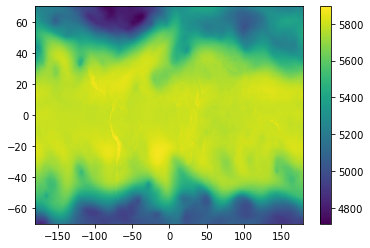

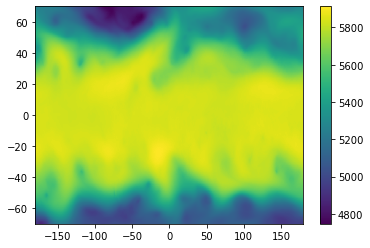

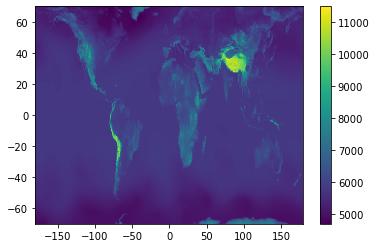

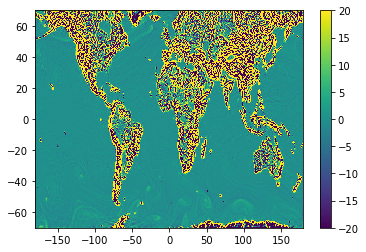

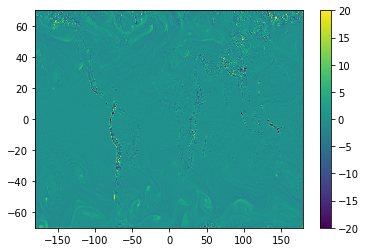

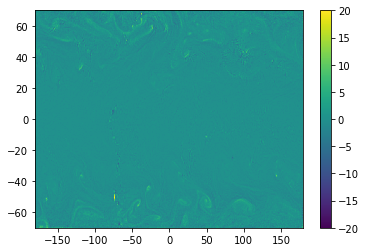

In [32]:
from scipy.ndimage import uniform_filter

x,y = np.meshgrid(elon, elat)
plt.pcolormesh(x,y,get_var_p_lvl(ehgt[0], ehypso[0], 500) ); plt.colorbar()
plt.figure()
plt.pcolormesh(x,y,get_var_p_lvl(ehgt[0], ep_3d, 500) ); plt.colorbar()
plt.figure()
plt.pcolormesh(x,y,get_var_p_lvl(ehypso_z[0], ep_3d, 500)); plt.colorbar()

laplacian = np.array(mpcalc.laplacian(uniform_filter(get_var_p_lvl(ehypso_z[0], ep_3d, 500) ),deltas=[dy,dx])*1e9)
plt.figure()
plt.pcolormesh(x,y,laplacian, vmin=-20, vmax=20); plt.colorbar()

laplacian = np.array(mpcalc.laplacian(uniform_filter(get_var_p_lvl(ehgt[0], ehypso[0], 500) ),deltas=[dy,dx])*1e9)
plt.figure()
plt.pcolormesh(x,y,laplacian, vmin=-20, vmax=20); plt.colorbar()

laplacian = np.array(mpcalc.laplacian(uniform_filter(get_var_p_lvl(ehgt[0], ep_3d, 500) ),deltas=[dy,dx])*1e9)
plt.figure()
plt.pcolormesh(x,y,laplacian, vmin=-20, vmax=20); plt.colorbar()

In [26]:
eta

array([[[[-23.62839536, -23.85196948, -24.02127804, ..., -23.32450821,
          -23.32016696, -23.42869809],
         [-22.70805141, -22.87735997, -23.16171152, ..., -22.90774868,
          -22.83177689, -22.71456328],
         [-22.30648624, -22.53223099, -22.87735997, ..., -21.94182166,
          -22.14586018, -22.2153201 ],
         ...,
         [  0.93871039,   0.94522226,   0.96041661, ...,   0.92568665,
            0.92785728,   0.93219852],
         [  0.74118374,   0.74552498,   0.74986623, ...,   0.69125942,
            0.71079502,   0.73033063],
         [  0.55885145,   0.58272829,   0.60009328, ...,   0.43512596,
            0.47853841,   0.52412149]],

        [[-22.71890452, -22.69285705, -22.59300842, ..., -22.26741504,
          -22.44757671, -22.62773838],
         [-21.98740473, -22.11113022, -22.18276076, ..., -21.54242711,
          -21.64227575, -21.81375493],
         [-21.5988633 , -21.71607692, -21.80290182, ..., -21.38180105,
          -21.42087225, -21.48816